# Cross-border legal interoperability visualizations — annotated exploratory notebook

This notebook provides a structured exploratory analysis of a **directional, categorical, country-by-country legal interoperability matrix** for cross-border biomedical and neurodata transfer. The central object is a matrix in which rows represent **origin/exporting jurisdictions**, columns represent **destination/receiving jurisdictions**, and each cell encodes the legal compatibility class for that directed transfer.

The analytical strategy proceeds from the most complete representation of the data to progressively more compressed summaries. The first figures preserve the full directed matrix. Subsequent figures summarize rows, columns, asymmetries, networks, latent country profiles, regional aggregates, and inequality in legal friction. This progression is deliberate: each section asks what information can be gained by simplifying the matrix, while also making explicit what information is lost by each simplification.

The compatibility classes are treated as ordered categories for several analyses:

- **A1**: directly enabled, same legal space.
- **A2**: directly enabled through adequacy or high convergence.
- **B**: permissible with standard transfer tools, such as a data transfer agreement.
- **C**: permissible but legally conditional or friction-heavy.
- **D**: restricted or difficult.
- **E**: legally uncertain or not presently supported.

For quantitative summaries, the classes are encoded as an ordinal legal-friction scale from A1 = 0 to E = 5. This encoding should be interpreted as an analytical approximation rather than a claim that the intervals between legal classes are exactly equal. It is useful for visualization, clustering, and summary statistics, but the categorical meaning of each class should remain central to interpretation.

## Setup

This section establishes the shared assumptions and visual grammar used throughout the notebook. The most important decision is to define a single ordered category system and a single color palette, so that all subsequent figures can be compared directly. The path `DATA_FILE` should point to the Excel matrix on your local disk. The helper functions load the matrix, harmonize country labels, convert categories into ordinal values, remove self-transfers safely, and save figures in both PNG and PDF formats.

Self-transfers are removed from most summary analyses because they do not represent cross-border data sharing. In many legal matrices, the diagonal is expected to be A1 by construction. Including it would inflate estimates of direct compatibility and obscure the structure of genuine cross-jurisdiction transfer.

In [1]:
# If needed, install packages in the current Jupyter kernel:
# import sys
# !{sys.executable} -m pip install openpyxl geopandas networkx scikit-learn plotly

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, TwoSlopeNorm
import matplotlib.patches as mpatches

DATA_FILE = Path("/Users/fp4834/Downloads/data-sharing-matrix.xlsx")

OUTDIR = Path("outputs")
OUTDIR.mkdir(exist_ok=True)

CATEGORY_ORDER = ["A1", "A2", "B", "C", "D", "E"]

CATEGORY_LABELS = [
    "A1 — directly enabled (same legal space)",
    "A2 — directly enabled (adequacy / high convergence)",
    "B — permissible with standard transfer tools (DTA)",
    "C — permissible but legally conditional / friction heavy",
    "D — restricted / difficult",
    "E — legally uncertain / not presently supported",
]

CATEGORY_TO_VALUE = {label: i for i, label in enumerate(CATEGORY_ORDER)}
VALUE_TO_CATEGORY = {v: k for k, v in CATEGORY_TO_VALUE.items()}

# Custom desaturated publication palette.
PALETTE = {
    "A1": "#4C9085",  # muted teal green
    "A2": "#8AB9A7",  # pale sage
    "B":  "#D8C77A",  # muted straw
    "C":  "#D49A6A",  # soft ochre / tan-orange
    "D":  "#B96B64",  # muted terracotta
    "E":  "#6E5A6A",  # muted plum-gray
}

CMAP = ListedColormap([PALETTE[c] for c in CATEGORY_ORDER])
NORM = BoundaryNorm(np.arange(-0.5, len(CATEGORY_ORDER) + 0.5, 1), CMAP.N)

plt.rcParams["figure.dpi"] = 120


In [2]:
def load_directional_matrix(path):
    """Load and clean the directional compatibility matrix.

    Rows are origin/exporting jurisdictions.
    Columns are destination/receiving jurisdictions.
    """
    df = pd.read_excel(path, index_col=0)
    df.index = df.index.map(lambda x: str(x).strip())
    df.columns = df.columns.map(lambda x: str(x).strip())

    # Harmonize occasional miscoding.
    df = df.replace({"1A": "A1"})

    # Retain jurisdictions present on both axes.
    common = [c for c in df.index if c in df.columns]
    df = df.loc[common, common]
    return df


def categorical_to_numeric(df):
    return df.replace(CATEGORY_TO_VALUE).apply(pd.to_numeric, errors="coerce")


def remove_self_transfers(df):
    """Return a copy of df with diagonal/self-transfers set to NaN.

    This avoids modifying df.values directly, which can trigger
    `ValueError: underlying array is read-only` in some environments.
    """
    arr = df.to_numpy(copy=True, dtype=object)
    np.fill_diagonal(arr, np.nan)
    return pd.DataFrame(arr, index=df.index.copy(), columns=df.columns.copy())

def mode_or_nan(values):
    counts = pd.Series(values).dropna().value_counts()
    if counts.empty:
        return np.nan
    return counts.idxmax()


def add_category_colorbar(fig, ax, im, label="Directional transfer compatibility class"):
    cbar = fig.colorbar(im, ax=ax, ticks=range(len(CATEGORY_ORDER)), fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels(CATEGORY_LABELS, fontsize=9)
    cbar.set_label(label, fontsize=11)
    return cbar


def savefig(fig, name):
    fig.savefig(OUTDIR / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTDIR / f"{name}.pdf", bbox_inches="tight")


df = load_directional_matrix(DATA_FILE)
df_no_self = remove_self_transfers(df)
numeric = categorical_to_numeric(df)
numeric_no_self = categorical_to_numeric(df_no_self)

df.head()


,Germany,France,Italy,Spain,Netherlands,Belgium,Sweden,Austria,Finland,Ireland,...,Honduras,Jamaica,Mexico,Nicaragua,Panama,Paraguay,Peru,Saint Lucia,Trinidad and Tobago,Uruguay
Germany,A1,A1,A1,A1,A1,A1,A1,A1,A1,A1,...,D,C,C,C,C,C,C,C,C,C
France,A1,A1,A1,A1,A1,A1,A1,A1,A1,A1,...,D,C,C,C,C,C,C,C,C,C
Italy,A1,A1,A1,A1,A1,A1,A1,A1,A1,A1,...,D,C,C,C,C,C,C,C,C,C
Spain,A1,A1,A1,A1,A1,A1,A1,A1,A1,A1,...,D,C,C,C,C,C,C,C,C,C
Netherlands,A1,A1,A1,A1,A1,A1,A1,A1,A1,A1,...,D,C,C,C,C,C,C,C,C,C


## 1. Directional matrix plot

The first analytical step is to inspect the full directed matrix before applying any statistical reduction. This plot preserves the most information: every country-to-country relationship remains visible, and directionality is retained. The row jurisdiction is the exporter of data, and the column jurisdiction is the receiver.

This figure should be read as the empirical foundation for all later summaries. Blocks of similar color suggest groups of jurisdictions with similar interoperability relationships. Sharp horizontal patterns indicate countries with broadly permissive or restrictive **export** profiles. Sharp vertical patterns indicate countries that are broadly easy or difficult to send data **to**. Because the matrix is directional, the upper and lower triangles need not match.

The purpose of this section is not only visualization. It establishes the baseline structure against which all subsequent summaries should be checked. If later compressed plots appear surprising, the matrix is the figure to return to for validation.

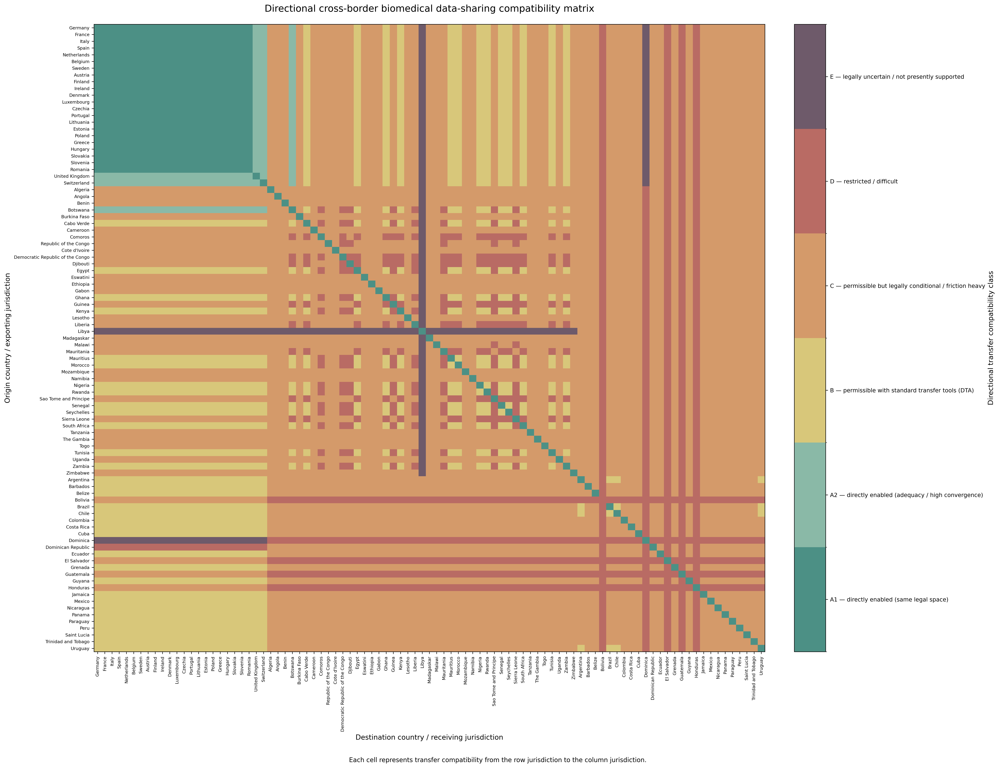

In [3]:
countries = list(numeric.index)

fig, ax = plt.subplots(figsize=(22, 17), dpi=300)

im = ax.imshow(
    numeric.values.astype(float),
    cmap=CMAP,
    norm=NORM,
    interpolation="none",
    aspect="auto",
)

ax.set_xticks(range(len(countries)))
ax.set_yticks(range(len(countries)))
ax.set_xticklabels(countries, rotation=90, fontsize=7)
ax.set_yticklabels(countries, fontsize=7)

add_category_colorbar(fig, ax, im)

ax.set_title("Directional cross-border biomedical data-sharing compatibility matrix", fontsize=15, pad=20)
ax.set_xlabel("Destination country / receiving jurisdiction", fontsize=11)
ax.set_ylabel("Origin country / exporting jurisdiction", fontsize=11)

fig.text(
    0.5, 0.01,
    "Each cell represents transfer compatibility from the row jurisdiction to the column jurisdiction.",
    ha="center", va="bottom", fontsize=10
)

fig.tight_layout(rect=[0, 0.03, 1, 1])
savefig(fig, "01_directional_matrix_custom_palette")
plt.show()


### Interpretation of the directional matrix

The matrix should be interpreted as the least compressed representation of the dataset. A visually coherent block indicates that many jurisdictions share similar legal compatibility relationships with one another. A heterogeneous row indicates that the exporting jurisdiction faces different legal conditions depending on the destination. A heterogeneous column indicates that the receiving jurisdiction is treated differently depending on the exporter.

Because the plot uses a categorical palette, adjacent colors should not be interpreted as continuous physical gradients. Instead, the colors encode ordered legal states. The primary interpretive questions are: whether compatibility is clustered by geography or legal family, whether certain jurisdictions appear as broad interoperability hubs, and whether the direction of transfer produces visually detectable asymmetry. The following sections progressively quantify these patterns.

## 2. Per-country stacked distribution plot

Continuing from the full matrix, this section compresses each row into a distribution over legal classes. Instead of asking which class applies to every specific destination, the plot asks: **what is the overall export profile of each jurisdiction?**

For each country, the row of the matrix is converted into proportions across A1, A2, B, C, D, and E after removing self-transfers. The resulting horizontal stacked bar is a summary of how that country behaves as an exporting jurisdiction across all destination countries. This is a row-wise composition analysis.

This plot is useful because it makes country-level heterogeneity more readable than the full matrix. However, it also discards the identity of the destination countries. Two countries can have identical stacked profiles while interacting with different specific partners.

In [4]:
rows = []
for country in df_no_self.index:
    values = pd.Series(df_no_self.loc[country].values).dropna()
    freq = values.value_counts(normalize=True).reindex(CATEGORY_ORDER).fillna(0)
    rows.append(freq)

outgoing_dist = pd.DataFrame(rows, index=df_no_self.index)
outgoing_dist = outgoing_dist.sort_values(by="A1", ascending=False)

countries_sorted = outgoing_dist.index.tolist()
y_pos = np.arange(len(countries_sorted))

fig_height = max(10, len(countries_sorted) * 0.8)
fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)

left = np.zeros(len(countries_sorted))
for category in CATEGORY_ORDER:
    vals = outgoing_dist[category].values
    ax.barh(y_pos, vals, left=left, height=0.6, color=PALETTE[category], label=category)
    left += vals

ax.set_yticks(y_pos)
ax.set_yticklabels(countries_sorted, fontsize=10.5)
ax.set_xlabel("Proportion of outgoing transfers", fontsize=11)
ax.set_ylabel("Country / origin jurisdiction", fontsize=11)
ax.set_title("Per-country distribution of outgoing transfer compatibility classes", fontsize=14, pad=14)
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
savefig(fig, "02_per_country_outgoing_distribution")
plt.show()


### Interpretation of the per-country outgoing distribution

Countries with bars dominated by A1, A2, or B have comparatively permissive or operationally feasible export profiles. Countries with large C, D, or E components face greater conditionality, restriction, or uncertainty when exporting data. The ordering by A1 proportion is mainly a readability device; it places more directly enabled exporters toward one end of the plot.

This figure should be interpreted together with the directional matrix. The stacked plot tells us how much legal friction characterizes each origin country overall, but the matrix identifies which bilateral relationships produce that friction. Thus, the stacked plot is a country-level summary, whereas the matrix remains the relationship-level evidence.

## 3. Import and export mode world maps

The previous section summarized each country by the full distribution of outgoing classes. This section compresses even further: it assigns each country a single modal class. The export mode is the most frequent class across a country’s row, and the import mode is the most frequent class across a country’s column.

The export map answers: **what is the dominant legal compatibility class when this country exports data to others?** The import map answers: **what is the dominant legal compatibility class when other countries send data to this country?**

This is a highly communicative geographic summary, but it is also a strong compression. The mode does not distinguish between a country that is 90% A1 and a country that is 35% A1, 33% B, and 32% C. Therefore, mode maps should be used as overview figures and interpreted alongside the stacked distributions and entropy measures.

In [6]:
# Install geopandas locally if needed:
# pip install geopandas

WORLD_FILE = Path("ne_110m_admin_0_countries.shp")  # Change this path to your Natural Earth .shp or .geojson file.

NAME_TO_NATURAL_EARTH = {
    "United Kingdom": "United Kingdom",
    "United States": "United States of America",
    "USA": "United States of America",
    "Czechia": "Czechia",
    "Democratic Republic of the Congo": "Dem. Rep. Congo",
    "Republic of the Congo": "Congo",
    "Côte d’Ivoire": "Côte d'Ivoire",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Eswatini": "eSwatini",
    "South Sudan": "S. Sudan",
    "Central African Republic": "Central African Rep.",
}

export_mode = df_no_self.apply(lambda row: mode_or_nan(row.values), axis=1)
import_mode = df_no_self.apply(lambda col: mode_or_nan(col.values), axis=0)

mode_df = pd.DataFrame({
    "country": df_no_self.index,
    "export_mode": export_mode.values,
    "import_mode": import_mode.reindex(df_no_self.index).values,
})
mode_df["map_name"] = mode_df["country"].replace(NAME_TO_NATURAL_EARTH)

mode_df.head()


,country,export_mode,import_mode,map_name
0,Germany,C,B,Germany
1,France,C,B,France
2,Italy,C,B,Italy
3,Spain,C,B,Spain
4,Netherlands,C,B,Netherlands


In [7]:
def try_load_world_map(world_file):
    try:
        import geopandas as gpd
    except ImportError:
        print("geopandas is not installed. Map rendering skipped.")
        return None

    if not world_file.exists():
        print(f"World map file not found: {world_file}. Map rendering skipped.")
        return None

    world = gpd.read_file(world_file)

    candidate_name_columns = ["NAME", "ADMIN", "name", "Name"]
    name_col = next((c for c in candidate_name_columns if c in world.columns), None)
    if name_col is None:
        raise ValueError(f"Could not identify a country-name column. Available columns: {list(world.columns)}")

    world = world.rename(columns={name_col: "map_name"})
    return world


world = try_load_world_map(WORLD_FILE)

if world is not None:
    merged = world.merge(mode_df, on="map_name", how="left")

    unmatched = sorted(set(mode_df["map_name"]) - set(world["map_name"]))
    print("Unmatched matrix countries requiring name harmonization:")
    print(unmatched)
else:
    merged = None
    print(mode_df)


geopandas is not installed. Map rendering skipped.
                country export_mode import_mode             map_name
0               Germany           C           B              Germany
1                France           C           B               France
2                 Italy           C           B                Italy
3                 Spain           C           B                Spain
4           Netherlands           C           B          Netherlands
..                  ...         ...         ...                  ...
88             Paraguay           C           C             Paraguay
89                 Peru           C           C                 Peru
90          Saint Lucia           C           C          Saint Lucia
91  Trinidad and Tobago           C           C  Trinidad and Tobago
92              Uruguay           C           C              Uruguay

[93 rows x 4 columns]


In [10]:
# World map loading cell
# This cell loads country boundaries for the import/export mode maps.
# It first tries WORLD_FILE. If that file is not found, it downloads
# Natural Earth Admin 0 countries automatically.
import sys

!{sys.executable} -m pip install geopandas pyogrio shapely fiona

from pathlib import Path
import zipfile
import urllib.request
import geopandas as gpd

WORLD_FILE = Path("ne_110m_admin_0_countries.shp")

NATURAL_EARTH_URL = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

MAP_DIR = Path("map_data")
MAP_DIR.mkdir(exist_ok=True)

ZIP_FILE = MAP_DIR / "ne_110m_admin_0_countries.zip"
DOWNLOADED_SHP = MAP_DIR / "ne_110m_admin_0_countries.shp"


def download_natural_earth_countries():
    """Download and unzip Natural Earth Admin 0 country boundaries."""
    if not DOWNLOADED_SHP.exists():
        print("Downloading Natural Earth country boundaries...")
        urllib.request.urlretrieve(NATURAL_EARTH_URL, ZIP_FILE)

        with zipfile.ZipFile(ZIP_FILE, "r") as z:
            z.extractall(MAP_DIR)

    return DOWNLOADED_SHP


def try_load_world_map(world_file):
    """Load country boundaries from a local file or Natural Earth fallback."""
    world_file = Path(world_file)

    if world_file.exists():
        print(f"Loading world map from local file: {world_file}")
        world = gpd.read_file(world_file)
    else:
        print(f"Local world map file not found: {world_file}")
        fallback_file = download_natural_earth_countries()
        print(f"Loading world map from downloaded file: {fallback_file}")
        world = gpd.read_file(fallback_file)

    candidate_name_columns = ["NAME", "ADMIN", "name", "Name"]

    name_col = next(
        (c for c in candidate_name_columns if c in world.columns),
        None,
    )

    if name_col is None:
        raise ValueError(
            "Could not identify a country-name column. "
            f"Available columns are: {list(world.columns)}"
        )

    world = world.rename(columns={name_col: "map_name"})

    return world


world = try_load_world_map(WORLD_FILE)

merged = world.merge(mode_df, on="map_name", how="left")

unmatched = sorted(set(mode_df["map_name"]) - set(world["map_name"]))

print("Unmatched matrix countries requiring name harmonization:")
print(unmatched)

print("\nMap data loaded successfully.")
print(f"Countries in matrix: {mode_df.shape[0]}")
print(f"Countries matched to map: {mode_df.shape[0] - len(unmatched)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 213.7 kB/s  0:01:56 eta 0:00:010:00:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 330.3 kB/s  0:00:044.3 kB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 204.8 kB/s  0:01:21 eta 0:00:010:03:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 175.1 kB/s  0:00:27174.5 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [geopandas]━ 6/7 [geopandas]na]plugins]
Local world map file not found: ne_110m_admin_0_countries.shp
Loading world map from downloaded file: map_data/ne_110m_admin_0_countries.shp
Unmatched matrix countries requiring name harmonization:
['Barbados', 'Cabo Verde', 'Comoros', 'Dominica', 'Dominican Republic', 'Grenada', 'Madagaskar', 'Mauritius', 'Saint Lucia', 'Sao Tome and Principe', 'Seychelles', 'The Gambia']

Map data loaded successfully.
Countries in matrix: 93
Countries matched to map: 81



Dominant import compatibility class by receiving jurisdiction
Countries in matrix: 93
Countries matched in map: 81


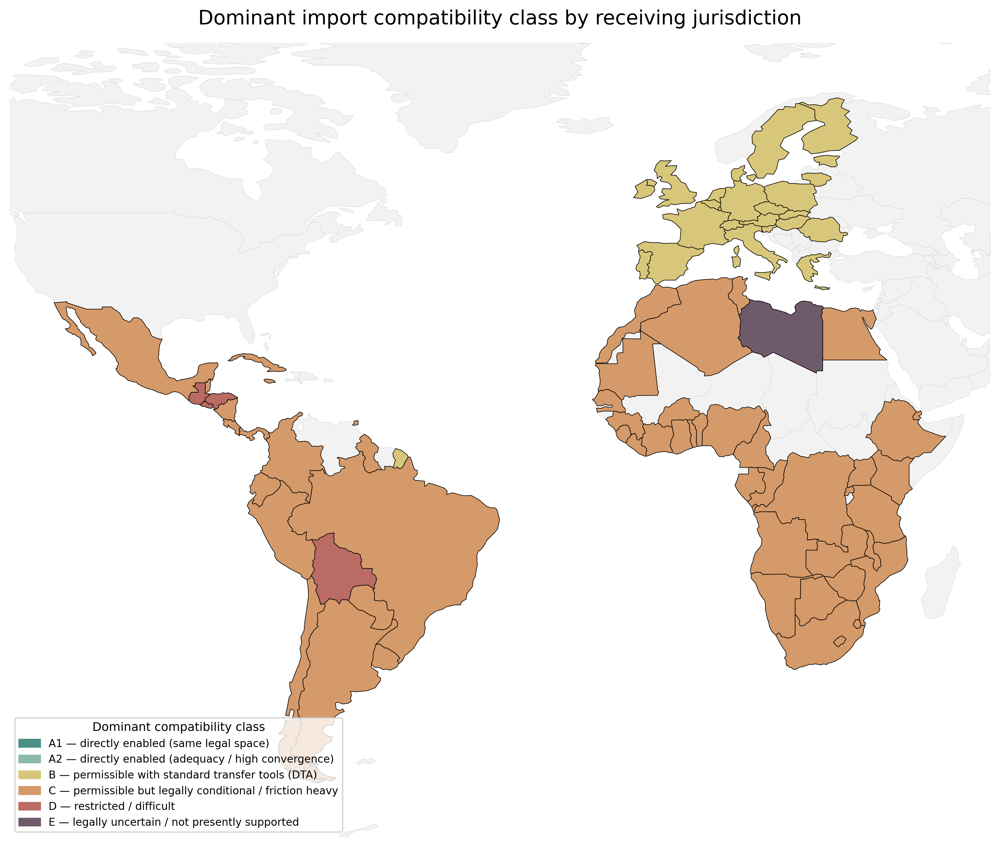


Dominant export compatibility class by exporting jurisdiction
Countries in matrix: 93
Countries matched in map: 81


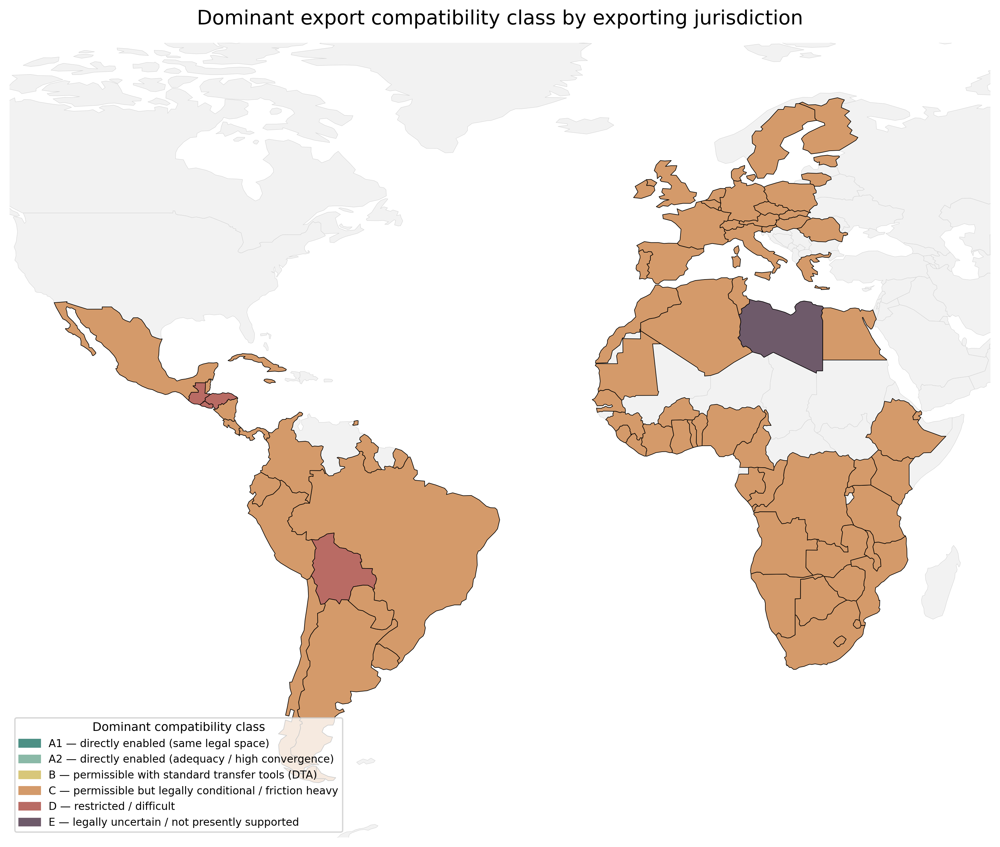

In [12]:
# Improved rendering cell for import/export mode maps
# Assumes `world`, `merged`, `mode_df`, `PALETTE`, `CATEGORY_ORDER`,
# `CATEGORY_LABELS`, and `savefig` already exist.

legend_handles = [
    mpatches.Patch(color=PALETTE[c], label=CATEGORY_LABELS[i])
    for i, c in enumerate(CATEGORY_ORDER)
]

def plot_mode_map(column, title, outfile_base):
    if merged is None:
        print(f"Skipping {title}: no world map file was loaded.")
        return

    matched = merged[merged[column].notna()].copy()

    print(f"\n{title}")
    print(f"Countries in matrix: {len(mode_df)}")
    print(f"Countries matched in map: {matched['map_name'].nunique()}")

    if matched.empty:
        print("No matched countries to plot.")
        return

    matched["plot_color"] = matched[column].map(PALETTE)

    fig, ax = plt.subplots(figsize=(16, 9), dpi=300)

    # Base world map
    world.plot(
        ax=ax,
        color="#F2F2F2",
        edgecolor="#D0D0D0",
        linewidth=0.25,
        zorder=1,
    )

    # Matched countries on top
    matched.plot(
        ax=ax,
        color=matched["plot_color"],
        edgecolor="black",
        linewidth=0.45,
        zorder=2,
    )

    # Zoom to matched countries with padding
    minx, miny, maxx, maxy = matched.total_bounds
    xpad = (maxx - minx) * 0.05
    ypad = (maxy - miny) * 0.08

    ax.set_xlim(minx - xpad, maxx + xpad)
    ax.set_ylim(miny - ypad, maxy + ypad)

    ax.set_title(title, fontsize=15, pad=14)
    ax.axis("off")

    ax.legend(
        handles=legend_handles,
        title="Dominant compatibility class",
        loc="lower left",
        frameon=True,
        fontsize=8,
        title_fontsize=9,
    )

    fig.tight_layout()
    savefig(fig, outfile_base)
    plt.show()


plot_mode_map(
    "import_mode",
    "Dominant import compatibility class by receiving jurisdiction",
    "03a_world_map_import_mode",
)

plot_mode_map(
    "export_mode",
    "Dominant export compatibility class by exporting jurisdiction",
    "03b_world_map_export_mode",
)

In [13]:
print("North America entries in mode_df:")
print(
    mode_df[
        mode_df["country"].str.contains("Canada|United|USA|Mexico", case=False, na=False)
    ][["country", "map_name", "import_mode", "export_mode"]]
)

print("\nNorth America entries in world map:")
print(
    world[
        world["map_name"].str.contains("Canada|United|America|Mexico", case=False, na=False)
    ][["map_name"]]
)

North America entries in mode_df:
           country        map_name import_mode export_mode
22  United Kingdom  United Kingdom           B           C
85          Mexico          Mexico           C           C

North America entries in world map:
                     map_name
3                      Canada
4    United States of America
27                     Mexico
84       United Arab Emirates
143            United Kingdom


### Interpretation of the modal maps

If a country appears with the same color in the import and export maps, its dominant legal profile is similar as a sender and receiver. If the colors differ, that country may occupy an asymmetric governance position: for example, it may commonly export under one class while receiving data under another.

Gray countries indicate that the country is present in the geographic boundary file but not matched to the matrix, or that no modal class could be assigned. If many relevant countries are gray, inspect the printed unmatched-country list and extend the `NAME_TO_NATURAL_EARTH` dictionary. Map interpretation is only as good as the country-name harmonization.

## 4. Asymmetry matrix

The previous sections examined export and import profiles separately. This section directly compares the two directions for every country pair. The asymmetry matrix asks whether the transfer from country *i* to country *j* has the same legal classification as the transfer from country *j* to country *i*.

The analysis computes:

\[
\Delta_{ij} = f(i \rightarrow j) - f(j \rightarrow i)
\]

where \(f\) maps A1 to 0 and E to 5. A value of 0 indicates reciprocity. A positive value means the row-to-column transfer is more difficult than the reverse direction. A negative value means it is easier than the reverse direction.

This section is crucial because a directional matrix may look similar to a symmetric matrix unless asymmetry is explicitly quantified. The diagnostic counts printed before the plot are as important as the plot itself: they reveal how common asymmetry is and how large it is.

Asymmetry value counts:
-1.0     628
 0.0    7300
 1.0     628
Name: count, dtype: int64

Asymmetry summary:
count    8556.000000
mean        0.000000
std         0.383164
min        -1.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
dtype: float64

Proportion symmetric (Δ = 0):
0.8532024310425432


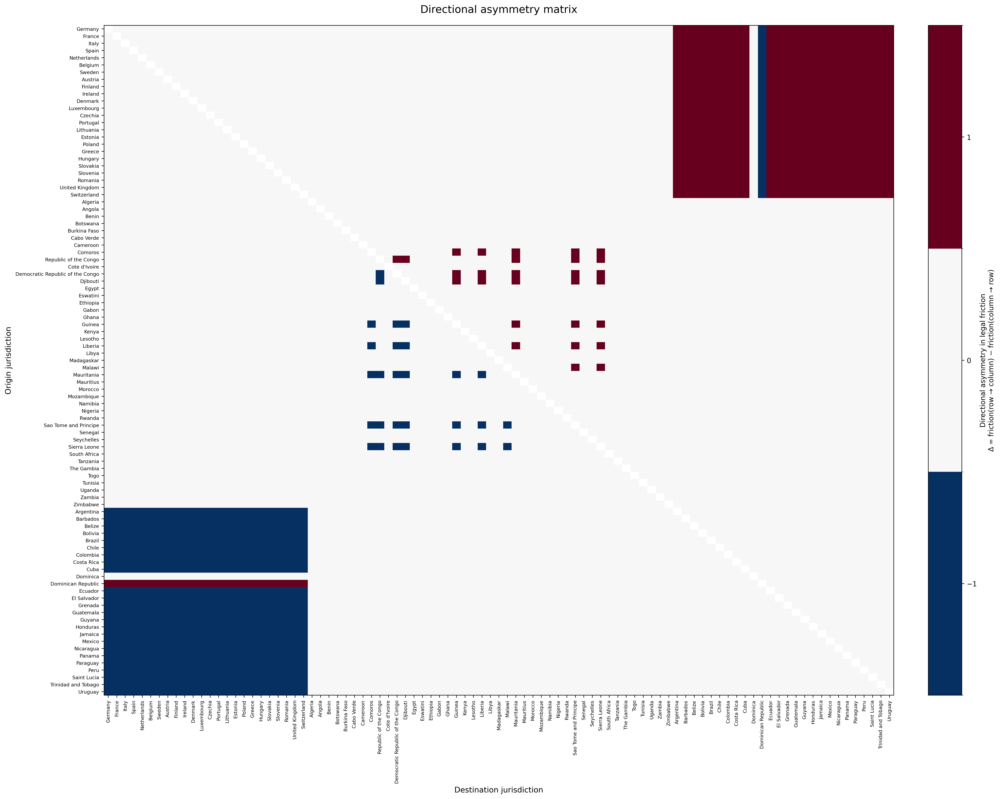

In [26]:
asymmetry = numeric - numeric.T
asymmetry = remove_self_transfers(asymmetry).apply(pd.to_numeric, errors="coerce")

# Diagnostic summary: check whether the matrix is truly symmetric or whether
# the visualization is hiding small directional differences.
asym_values = pd.Series(asymmetry.to_numpy(copy=True).flatten()).dropna()

print("Asymmetry value counts:")
print(asym_values.value_counts().sort_index())

print("\nAsymmetry summary:")
print(asym_values.describe())

print("\nProportion symmetric (Δ = 0):")
print((asym_values == 0).mean())

# Plot only integer asymmetry levels using a discrete diverging scale.
# This makes small ±1 or ±2 differences visible.
max_abs = int(np.nanmax(np.abs(asym_values)))
bounds = np.arange(-max_abs - 0.5, max_abs + 1.5, 1)

cmap = plt.get_cmap("RdBu_r", len(bounds) - 1)
norm_asym = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(20, 16), dpi=300)

im = ax.imshow(
    asymmetry.to_numpy(copy=True, dtype=float),
    cmap=cmap,
    norm=norm_asym,
    interpolation="none",
    aspect="auto",
)

ax.set_xticks(range(len(asymmetry.columns)))
ax.set_yticks(range(len(asymmetry.index)))
ax.set_xticklabels(asymmetry.columns, rotation=90, fontsize=7)
ax.set_yticklabels(asymmetry.index, fontsize=7)

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=np.arange(-max_abs, max_abs + 1, 1),
    fraction=0.046,
    pad=0.04,
)
cbar.set_label(
    "Directional asymmetry in legal friction\n"
    "Δ = friction(row → column) − friction(column → row)",
    fontsize=10,
)

ax.set_title(
    "Directional asymmetry matrix",
    fontsize=15,
    pad=18,
)
ax.set_xlabel("Destination jurisdiction", fontsize=11)
ax.set_ylabel("Origin jurisdiction", fontsize=11)

fig.tight_layout()
savefig(fig, "04_asymmetry_matrix_discrete")
plt.show()

### Interpretation of the asymmetry analysis

The first interpretation should come from the value counts. If most values are 0, the global matrix is largely reciprocal. If nonzero values are common, the legal landscape contains substantial direction-specific imbalance. If the maximum asymmetry is only ±1, then directional differences exist but are modest in magnitude. If larger values appear, some country pairs differ sharply depending on transfer direction.

In the current analysis, the diagnostic output previously indicated that approximately 85% of directed pairs were symmetric and that all observed asymmetries were limited to ±1. Under that result, the appropriate interpretation is that directionality matters, but the magnitude of legal imbalance is bounded. The scientific question then becomes less about how large asymmetries are and more about **where** they occur: which jurisdictions, regions, or legal mechanisms account for the nonreciprocal relationships.

## 5. Directed network analysis

Having quantified pairwise asymmetry, this section changes representation from a matrix to a graph. Countries are represented as nodes, and directed edges represent practically usable transfer relationships. By default, the network retains A1, A2, and B edges and excludes C, D, and E relationships.

This threshold is analytically important. If all edges are retained, the graph becomes visually saturated because almost every country is connected to many others. By keeping only operationally feasible transfers, the network focuses on the subset of relationships that could plausibly support routine cross-border biomedical data sharing.

Network analysis addresses a different question from the matrix: not simply what the pairwise legal state is, but which countries occupy structurally central positions in the usable transfer ecosystem.

In [12]:
# Install networkx locally if needed:
# pip install networkx

try:
    import networkx as nx
    HAS_NETWORKX = True
except ImportError:
    HAS_NETWORKX = False
    print("networkx is not installed. Network section skipped.")


networkx is not installed. Network section skipped.


In [13]:
if HAS_NETWORKX:
    THRESHOLD_MAX_VALUE = CATEGORY_TO_VALUE["B"]  # keep A1, A2, B

    G = nx.DiGraph()
    for c in numeric_no_self.index:
        G.add_node(c)

    for origin in numeric_no_self.index:
        for dest in numeric_no_self.columns:
            val = numeric_no_self.loc[origin, dest]
            if pd.notna(val) and val <= THRESHOLD_MAX_VALUE:
                # Stronger edge for easier transfer.
                weight = (THRESHOLD_MAX_VALUE + 1) - val
                G.add_edge(origin, dest, weight=float(weight), category=VALUE_TO_CATEGORY[int(val)])

    out_strength = dict(G.out_degree(weight="weight"))
    in_strength = dict(G.in_degree(weight="weight"))
    betweenness = nx.betweenness_centrality(G, weight=None, normalized=True)

    centrality_df = pd.DataFrame({
        "country": list(G.nodes),
        "out_strength": [out_strength.get(n, 0) for n in G.nodes],
        "in_strength": [in_strength.get(n, 0) for n in G.nodes],
        "betweenness": [betweenness.get(n, 0) for n in G.nodes],
    }).sort_values("out_strength", ascending=False)

    display(centrality_df.head(15))

    # Stable spring layout for publication-like visualization.
    pos = nx.spring_layout(G, k=0.8, seed=7, weight="weight")

    fig, ax = plt.subplots(figsize=(16, 14), dpi=300)

    edge_widths = [0.25 + 0.8 * G[u][v]["weight"] for u, v in G.edges]
    node_sizes = [80 + 20 * (out_strength.get(n, 0) + in_strength.get(n, 0)) for n in G.nodes]

    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, alpha=0.18, arrows=True, arrowsize=6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color="#7D8FA6", edgecolors="white", linewidths=0.4)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)

    ax.set_title("Directed network of practically usable transfers (A1/A2/B)", fontsize=15, pad=15)
    ax.axis("off")

    fig.tight_layout()
    savefig(fig, "05_directed_network_thresholded")
    plt.show()


### Interpretation of the directed network

Node position is determined by the network layout and should be interpreted cautiously. More important are the computed centrality measures. Out-strength summarizes how broadly a jurisdiction can export through feasible relationships. In-strength summarizes how broadly it can receive data through feasible relationships. Betweenness centrality identifies jurisdictions that lie on many shortest paths and may therefore function as bridges or intermediaries in the interoperability structure.

A dense cluster of countries with many A1/A2/B edges suggests a legal interoperability bloc. Peripheral countries with few feasible edges may represent jurisdictions where data-sharing requires additional legal infrastructure, policy harmonization, or case-specific agreements. The network is best treated as an exploratory tool for identifying hubs, bridges, and isolated jurisdictions, not as a substitute for the full matrix.

## 6. Country legal-profile embeddings and clustering

The previous section represented the data as a network of feasible directed transfers. This section returns to the country profiles themselves. Each country is treated as a vector of legal-friction values across all destinations. Countries with similar vectors have similar export profiles, even if they are geographically distant.

The goal is to discover whether the legal-interoperability matrix contains lower-dimensional structure: clusters, gradients, or latent axes of governance similarity. Several methods are included because each answers a slightly different question. PCA is linear and interpretable. Hierarchical clustering emphasizes group structure. MDS preserves pairwise distances. t-SNE and UMAP are nonlinear exploratory methods that may reveal local neighborhoods but require more caution in interpretation.

In [14]:
# Install scikit-learn locally if needed:
# pip install scikit-learn

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print("scikit-learn is not installed. PCA embedding skipped.")


### 6.1 PCA: linear embedding of outgoing legal profiles

PCA identifies orthogonal axes that explain the largest amount of variance in the country-by-destination profile matrix. If countries align along a single diagonal or line, that often means the dominant structure is close to one-dimensional: countries primarily differ by overall legal friction rather than by multiple independent patterns.

PCA is useful because the axes are mathematically transparent. However, when many country labels overlap, the plot may be difficult to read visually. In that case, the result is still informative: it suggests that PCA may be summarizing a broad gradient rather than revealing discrete clusters.

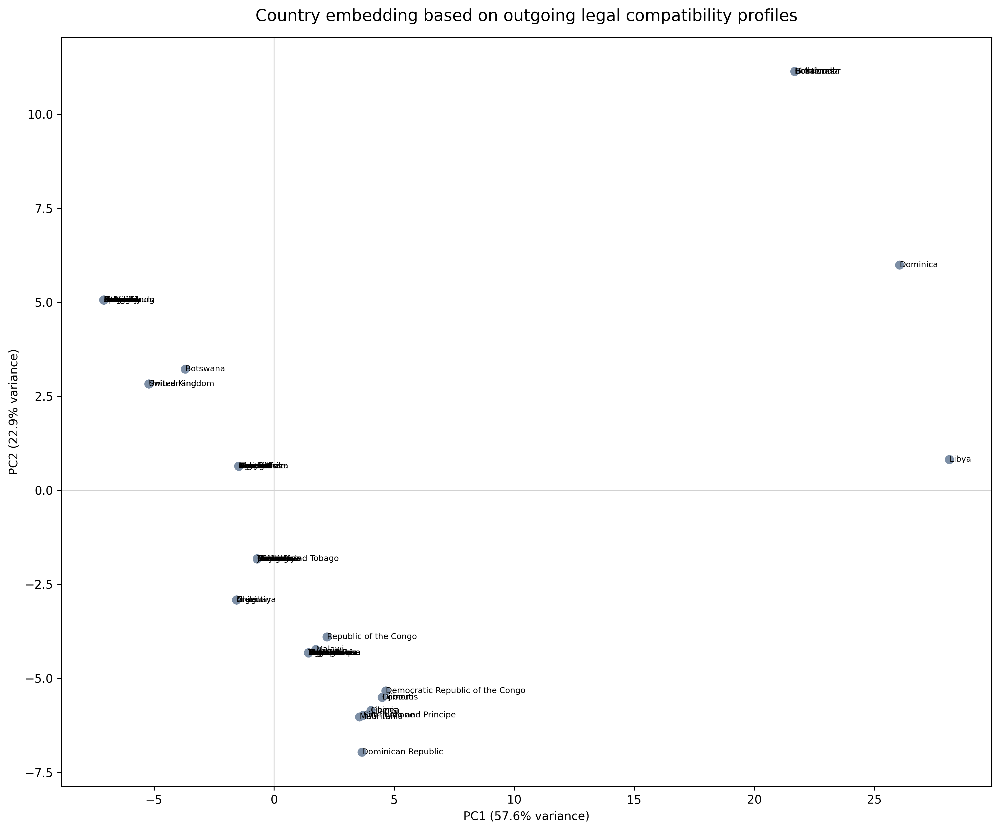

In [15]:
if HAS_SKLEARN:
    # Fill missing values with column medians, then global median if needed.
    X = numeric_no_self.copy().astype(float)
    X = X.apply(lambda col: col.fillna(col.median()), axis=0)
    X = X.fillna(np.nanmedian(X.values))

    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2, random_state=7)
    coords = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame({
        "country": X.index,
        "PC1": coords[:, 0],
        "PC2": coords[:, 1],
    })

    fig, ax = plt.subplots(figsize=(12, 10), dpi=300)
    ax.scatter(pca_df["PC1"], pca_df["PC2"], s=45, color="#7D8FA6")

    for _, row in pca_df.iterrows():
        ax.text(row["PC1"], row["PC2"], row["country"], fontsize=7, ha="left", va="center")

    ax.axhline(0, color="lightgray", linewidth=0.8)
    ax.axvline(0, color="lightgray", linewidth=0.8)

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
    ax.set_title("Country embedding based on outgoing legal compatibility profiles", fontsize=14, pad=14)

    fig.tight_layout()
    savefig(fig, "06_country_profile_pca_embedding")
    plt.show()


#### Interpretation of the PCA embedding

Countries that appear close together in PCA space have similar outgoing legal compatibility profiles. A long one-dimensional arrangement suggests a primary gradient from more permissive to more restrictive profiles. Distinct clusters would suggest qualitatively different governance regimes.

If the plot shows substantial label overlap, this should not automatically be treated as a failure. It may indicate that the data do not strongly support separation into many independent dimensions. The subsequent clustering, MDS, t-SNE, and UMAP sections test whether alternative representations provide clearer structure.

### 6.2 Clustered heatmap: reordering the matrix by profile similarity

The clustered heatmap takes the original matrix and reorders countries according to hierarchical clustering of their outgoing profiles. Unlike PCA, which projects countries into two dimensions, this approach preserves the matrix format while placing similar countries near one another.

The method computes a distance between every pair of country export profiles and then builds a hierarchical tree using average linkage. The resulting order is used to reorder both rows and columns. This can reveal governance blocs as contiguous blocks of similar colors.

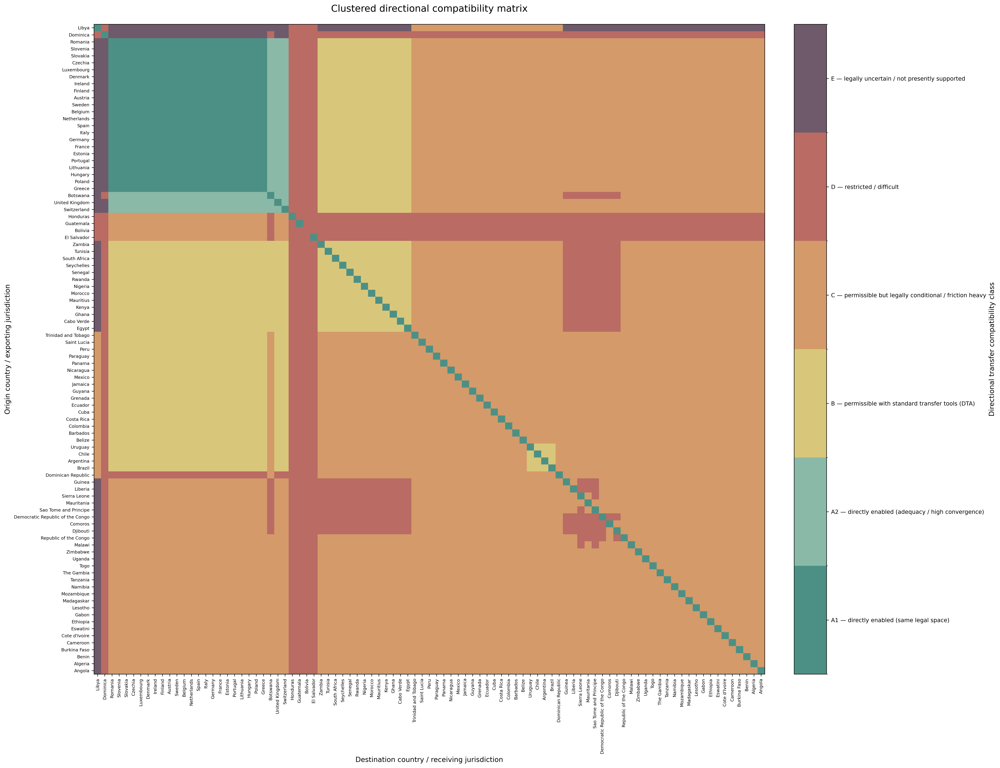

In [27]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

X = numeric_no_self.copy().astype(float)

# Fill missing values conservatively
X = X.apply(lambda col: col.fillna(col.median()), axis=0)
X = X.fillna(np.nanmedian(X.values))

# Cluster countries by outgoing profiles
row_dist = pdist(X.values, metric="euclidean")
row_linkage = linkage(row_dist, method="average")
row_order = leaves_list(row_linkage)

ordered_countries = X.index[row_order]
X_clustered = numeric.loc[ordered_countries, ordered_countries]

fig, ax = plt.subplots(figsize=(22, 17), dpi=300)

im = ax.imshow(
    X_clustered.values.astype(float),
    cmap=CMAP,
    norm=NORM,
    interpolation="none",
    aspect="auto",
)

ax.set_xticks(range(len(ordered_countries)))
ax.set_yticks(range(len(ordered_countries)))
ax.set_xticklabels(ordered_countries, rotation=90, fontsize=7)
ax.set_yticklabels(ordered_countries, fontsize=7)

add_category_colorbar(fig, ax, im)

ax.set_title(
    "Clustered directional compatibility matrix",
    fontsize=15,
    pad=20,
)
ax.set_xlabel("Destination country / receiving jurisdiction", fontsize=11)
ax.set_ylabel("Origin country / exporting jurisdiction", fontsize=11)

fig.tight_layout()
savefig(fig, "06b_clustered_directional_heatmap")
plt.show()

#### Interpretation of the clustered heatmap

Blocks along the diagonal indicate groups of countries that are mutually similar in their legal compatibility profiles. Off-diagonal blocks reveal how one cluster relates to another. If the clustered heatmap reveals sharper visual structure than the original matrix, it suggests that legal interoperability is organized by latent governance clusters rather than by the original country order.

This figure is often more interpretable than a PCA scatterplot for categorical matrices because it preserves the full relationship structure while improving the ordering of rows and columns.

### 6.3 MDS: distance-preserving country embedding

Multidimensional Scaling (MDS) represents countries in two dimensions while attempting to preserve the pairwise distances between their legal profiles. Whereas PCA maximizes explained variance along linear axes, MDS begins from a distance matrix and tries to maintain similarity relationships directly.

This makes MDS attractive for this dataset because the substantive question is relational: which countries have similar profiles of legal compatibility toward the rest of the world?

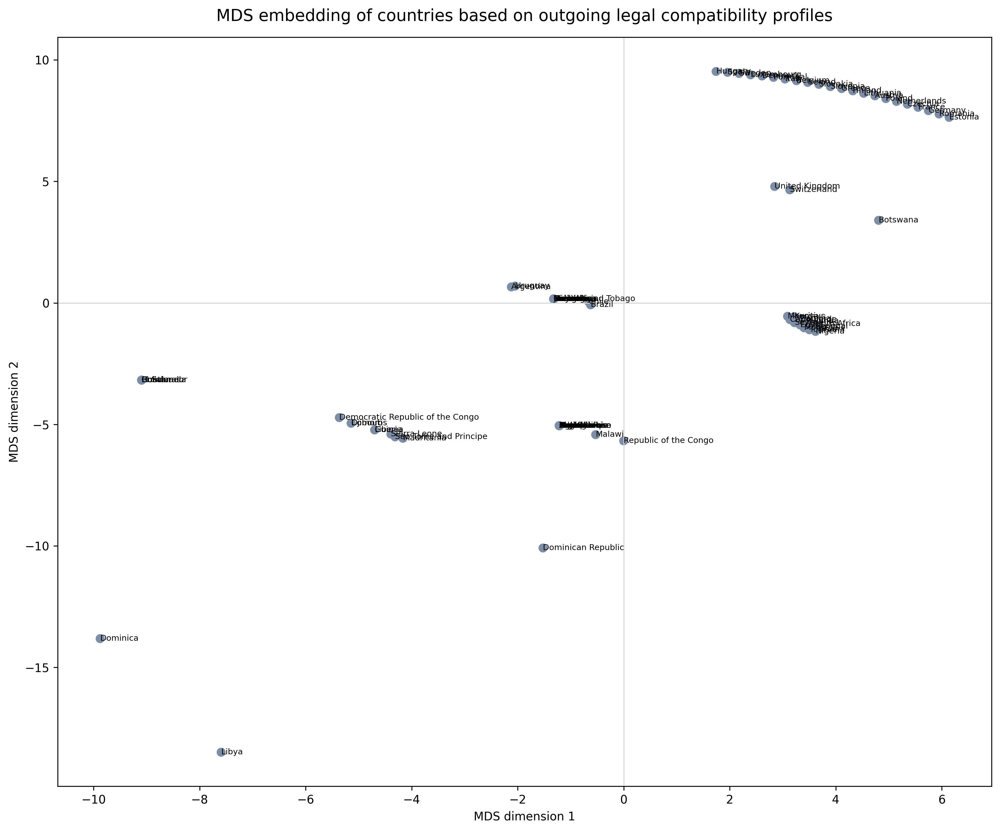

In [28]:
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform

X = numeric_no_self.copy().astype(float)

# Fill missing values
X = X.apply(lambda col: col.fillna(col.median()), axis=0)
X = X.fillna(np.nanmedian(X.values))

# Compute pairwise distances between countries based on outgoing profiles
distance_matrix = squareform(pdist(X.values, metric="euclidean"))

mds = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=7,
    normalized_stress="auto",
)

coords = mds.fit_transform(distance_matrix)

mds_df = pd.DataFrame({
    "country": X.index,
    "MDS1": coords[:, 0],
    "MDS2": coords[:, 1],
})

fig, ax = plt.subplots(figsize=(12, 10), dpi=300)

ax.scatter(
    mds_df["MDS1"],
    mds_df["MDS2"],
    s=45,
    color="#7D8FA6",
)

for _, row in mds_df.iterrows():
    ax.text(
        row["MDS1"],
        row["MDS2"],
        row["country"],
        fontsize=7,
        ha="left",
        va="center",
    )

ax.axhline(0, color="lightgray", linewidth=0.8)
ax.axvline(0, color="lightgray", linewidth=0.8)

ax.set_xlabel("MDS dimension 1")
ax.set_ylabel("MDS dimension 2")
ax.set_title(
    "MDS embedding of countries based on outgoing legal compatibility profiles",
    fontsize=14,
    pad=14,
)

fig.tight_layout()
savefig(fig, "06c_country_profile_mds_embedding")
plt.show()

#### Interpretation of the MDS embedding

Countries close together in the MDS plot have similar outgoing legal-friction profiles. Distances between points are more directly meaningful than in t-SNE or UMAP because MDS explicitly attempts to preserve the original pairwise distance matrix.

If MDS separates countries more clearly than PCA, it suggests that the structure is not well summarized by linear variance axes alone. If MDS also collapses into a gradient, the data likely contain a dominant one-dimensional legal-friction continuum.

### 6.4 t-SNE: local-neighborhood exploratory embedding

t-SNE is a nonlinear visualization method designed to preserve local neighborhoods. It can be useful for detecting small groups of countries with very similar profiles, but it does not preserve global distances reliably. Two clusters that appear far apart in t-SNE space are not necessarily proportionally far apart in the original data.

For this reason, t-SNE should be treated as an exploratory diagnostic rather than a primary inferential figure. Its value is mainly in asking whether local neighborhoods appear that were not visible in PCA or MDS.

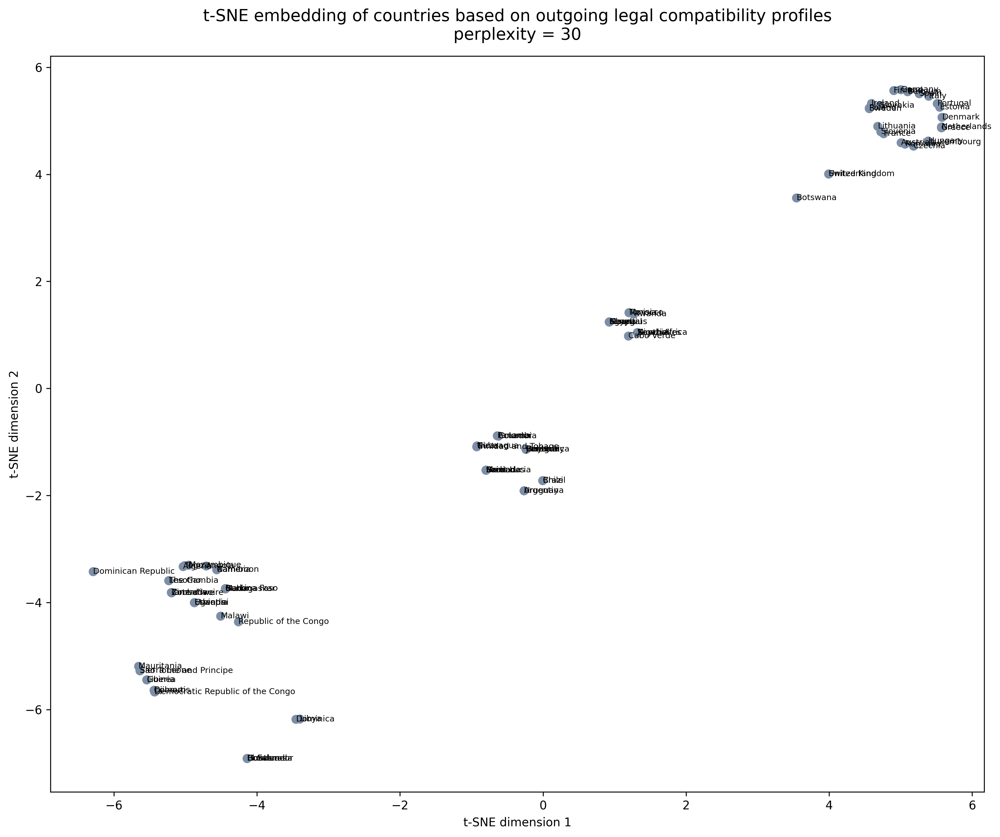

In [29]:
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist, squareform

X = numeric_no_self.copy().astype(float)

# Fill missing values
X = X.apply(lambda col: col.fillna(col.median()), axis=0)
X = X.fillna(np.nanmedian(X.values))

# Pairwise distances between countries based on outgoing profiles
distance_matrix = squareform(pdist(X.values, metric="euclidean"))

# t-SNE is sensitive to sample size. Perplexity must be less than n_samples.
n_samples = X.shape[0]
perplexity = min(30, max(5, (n_samples - 1) // 3))

tsne = TSNE(
    n_components=2,
    metric="precomputed",
    perplexity=perplexity,
    learning_rate="auto",
    init="random",
    random_state=7,
)

coords = tsne.fit_transform(distance_matrix)

tsne_df = pd.DataFrame({
    "country": X.index,
    "TSNE1": coords[:, 0],
    "TSNE2": coords[:, 1],
})

fig, ax = plt.subplots(figsize=(12, 10), dpi=300)

ax.scatter(
    tsne_df["TSNE1"],
    tsne_df["TSNE2"],
    s=45,
    color="#7D8FA6",
)

for _, row in tsne_df.iterrows():
    ax.text(
        row["TSNE1"],
        row["TSNE2"],
        row["country"],
        fontsize=7,
        ha="left",
        va="center",
    )

ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.set_title(
    f"t-SNE embedding of countries based on outgoing legal compatibility profiles\n"
    f"perplexity = {perplexity}",
    fontsize=14,
    pad=14,
)

fig.tight_layout()
savefig(fig, "06d_country_profile_tsne_embedding")
plt.show()

#### Interpretation of the t-SNE embedding

Interpret t-SNE by focusing on local neighborhoods: countries plotted close together are likely to have similar outgoing legal profiles. Avoid overinterpreting the distance between separated clusters or the overall orientation of the plot. Because t-SNE is sensitive to perplexity and random initialization, stable findings should be checked by rerunning with different seeds or perplexity values.

If t-SNE reveals groups that also appear in the clustered heatmap or MDS plot, those groups are more likely to reflect robust structure in the data.

### 6.5 UMAP: nonlinear embedding balancing local and global structure

UMAP is another nonlinear embedding method. Compared with t-SNE, it often preserves more of the broader global structure while still emphasizing local neighborhoods. The `n_neighbors` parameter controls the scale of structure emphasized: smaller values emphasize local neighborhoods, while larger values emphasize broader organization.

UMAP can be visually effective, but it is still an exploratory representation. It should be used to generate hypotheses about governance clusters, not to prove them.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 246.6 kB/s  0:00:10a 0:00:010:00:02:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 236.8 kB/s  0:03:12 eta 0:00:020:00:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn] 3/4 [umap-learn]]


/opt/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


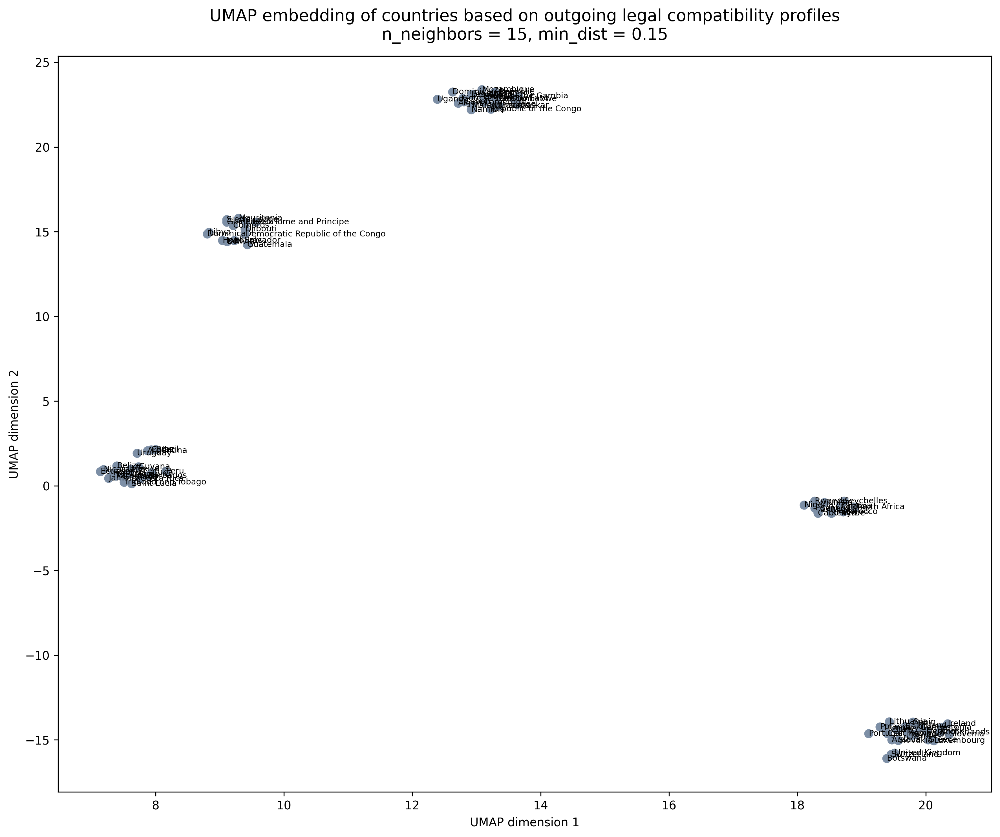

In [33]:
# If needed, install UMAP first:
# import sys
!pip install umap-learn

from scipy.spatial.distance import pdist, squareform

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print(
        "UMAP is not installed. Install it with: "
        "pip install umap-learn"
    )

if HAS_UMAP:
    X = numeric_no_self.copy().astype(float)

    # Fill missing values
    X = X.apply(lambda col: col.fillna(col.median()), axis=0)
    X = X.fillna(np.nanmedian(X.values))

    # Pairwise distances between countries based on outgoing profiles
    distance_matrix = squareform(pdist(X.values, metric="euclidean"))

    n_samples = X.shape[0]
    n_neighbors = min(15, max(3, n_samples // 5))

    reducer = umap.UMAP(
        n_components=2,
        metric="precomputed",
        n_neighbors=n_neighbors,
        min_dist=0.15,
        random_state=7,
    )

    coords = reducer.fit_transform(distance_matrix)

    umap_df = pd.DataFrame({
        "country": X.index,
        "UMAP1": coords[:, 0],
        "UMAP2": coords[:, 1],
    })

    fig, ax = plt.subplots(figsize=(12, 10), dpi=300)

    ax.scatter(
        umap_df["UMAP1"],
        umap_df["UMAP2"],
        s=45,
        color="#7D8FA6",
    )

    for _, row in umap_df.iterrows():
        ax.text(
            row["UMAP1"],
            row["UMAP2"],
            row["country"],
            fontsize=7,
            ha="left",
            va="center",
        )

    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_title(
        f"UMAP embedding of countries based on outgoing legal compatibility profiles\n"
        f"n_neighbors = {n_neighbors}, min_dist = 0.15",
        fontsize=14,
        pad=14,
    )

    fig.tight_layout()
    savefig(fig, "06e_country_profile_umap_embedding")
    plt.show()

#### Interpretation of the UMAP embedding

Countries close together in UMAP space have similar outgoing legal compatibility profiles under the chosen distance metric and parameter settings. If UMAP reveals clear clusters that correspond to known legal or regional groupings, this may indicate meaningful governance structure. If the plot is unstable across parameters, the apparent clusters should be treated cautiously.

For manuscript purposes, UMAP is strongest when used alongside the clustered heatmap. The heatmap provides a transparent relationship-level view, while UMAP provides an accessible two-dimensional summary.

## 7. Entropy / diversity profile and map

The preceding embeddings ask whether countries have similar profiles. This section asks a complementary question: **how heterogeneous is each country’s profile?** Entropy summarizes the diversity of legal classes within each country’s export or import relationships.

A country with low entropy has a relatively uniform profile: most transfers fall into the same class. A country with high entropy has a mixed profile: different destination or origin countries fall into different legal categories. Entropy therefore captures regulatory heterogeneity rather than permissiveness alone.

This is important because two countries can have the same modal class but very different distributions. Entropy helps distinguish a stable legal profile from a fragmented one.

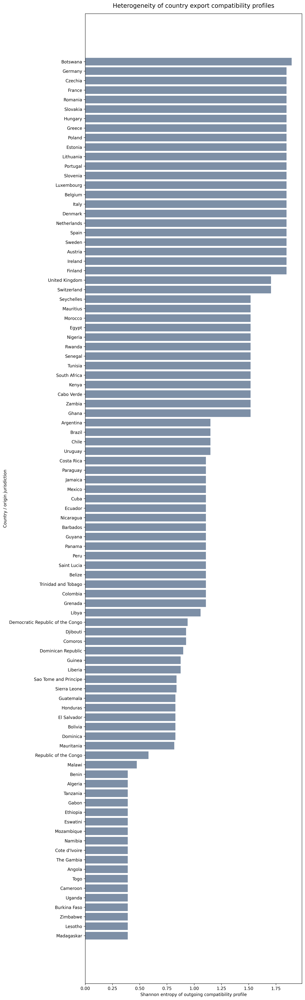

In [16]:
def shannon_entropy(categories):
    values = pd.Series(categories).dropna()
    if values.empty:
        return np.nan
    p = values.value_counts(normalize=True)
    return float(-(p * np.log2(p)).sum())


entropy_df = pd.DataFrame({
    "country": df_no_self.index,
    "export_entropy": df_no_self.apply(lambda row: shannon_entropy(row.values), axis=1).values,
    "import_entropy": df_no_self.apply(lambda col: shannon_entropy(col.values), axis=0).reindex(df_no_self.index).values,
})

entropy_sorted = entropy_df.sort_values("export_entropy", ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(entropy_sorted) * 0.35)), dpi=300)
ax.barh(entropy_sorted["country"], entropy_sorted["export_entropy"], color="#7D8FA6")
ax.invert_yaxis()
ax.set_xlabel("Shannon entropy of outgoing compatibility profile")
ax.set_ylabel("Country / origin jurisdiction")
ax.set_title("Heterogeneity of country export compatibility profiles", fontsize=14, pad=14)

fig.tight_layout()
savefig(fig, "07a_export_entropy_barplot")
plt.show()


In [17]:
def plot_entropy_map(column, title, outfile_base):
    if merged is None:
        print(f"Skipping {title}: no world map file was loaded.")
        return

    entropy_map_df = entropy_df.copy()
    entropy_map_df["map_name"] = entropy_map_df["country"].replace(NAME_TO_NATURAL_EARTH)

    map_merged = world.merge(entropy_map_df, on="map_name", how="left")

    fig, ax = plt.subplots(figsize=(14, 8), dpi=300)
    map_merged.plot(column=column, ax=ax, legend=True, cmap="magma", edgecolor="white", linewidth=0.35)

    ax.set_title(title, fontsize=15, pad=14)
    ax.axis("off")

    fig.tight_layout()
    savefig(fig, outfile_base)
    plt.show()


plot_entropy_map("import_entropy", "Import-profile entropy by receiving jurisdiction", "07b_world_map_import_entropy")
plot_entropy_map("export_entropy", "Export-profile entropy by exporting jurisdiction", "07c_world_map_export_entropy")


Skipping Import-profile entropy by receiving jurisdiction: no world map file was loaded.
Skipping Export-profile entropy by exporting jurisdiction: no world map file was loaded.


### Interpretation of entropy analyses

High export entropy indicates that a country’s outgoing transfer conditions vary substantially across destinations. Low export entropy indicates a more uniform export regime. High import entropy indicates that other countries face varied conditions when sending data to that country, whereas low import entropy indicates a more consistent receiving profile.

Entropy does not indicate whether a country is permissive or restrictive. It indicates whether its profile is homogeneous or heterogeneous. Therefore, entropy should be interpreted together with mean friction, mode, and stacked proportions.

## 8. Sankey / alluvial-style summary

The previous section measured heterogeneity country by country. This section aggregates across countries to examine how country-level dominant profiles relate to individual transfer-level classes. Each directed transfer is classified by the export-mode class of its origin country and by its actual bilateral transfer class.

The Sankey or alluvial representation shows whether countries with a given dominant profile mostly generate transfers of the same class, or whether their individual bilateral relationships spread across multiple classes. This is a bridge between country-level summaries and relationship-level data.

In [18]:
# Prepare transfer-level summary.
records = []
for origin in df_no_self.index:
    origin_mode = export_mode.loc[origin]
    for dest in df_no_self.columns:
        cls = df_no_self.loc[origin, dest]
        if pd.notna(cls):
            records.append({
                "origin": origin,
                "destination": dest,
                "origin_export_mode": origin_mode,
                "transfer_class": cls,
            })

flow_df = pd.DataFrame(records)
flow_counts = (
    flow_df
    .groupby(["origin_export_mode", "transfer_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=CATEGORY_ORDER, columns=CATEGORY_ORDER, fill_value=0)
)

display(flow_counts)


transfer_class,A1,A2,B,C,D,E
origin_export_mode,,,,,,
A1,0,0,0,0,0,0
A2,0,0,0,0,0,0
B,0,0,0,0,0,0
C,462,138,1298,5323,693,90
D,0,0,0,96,340,24
E,0,0,0,21,5,66


plotly is not installed. Static heatmap fallback will be used.


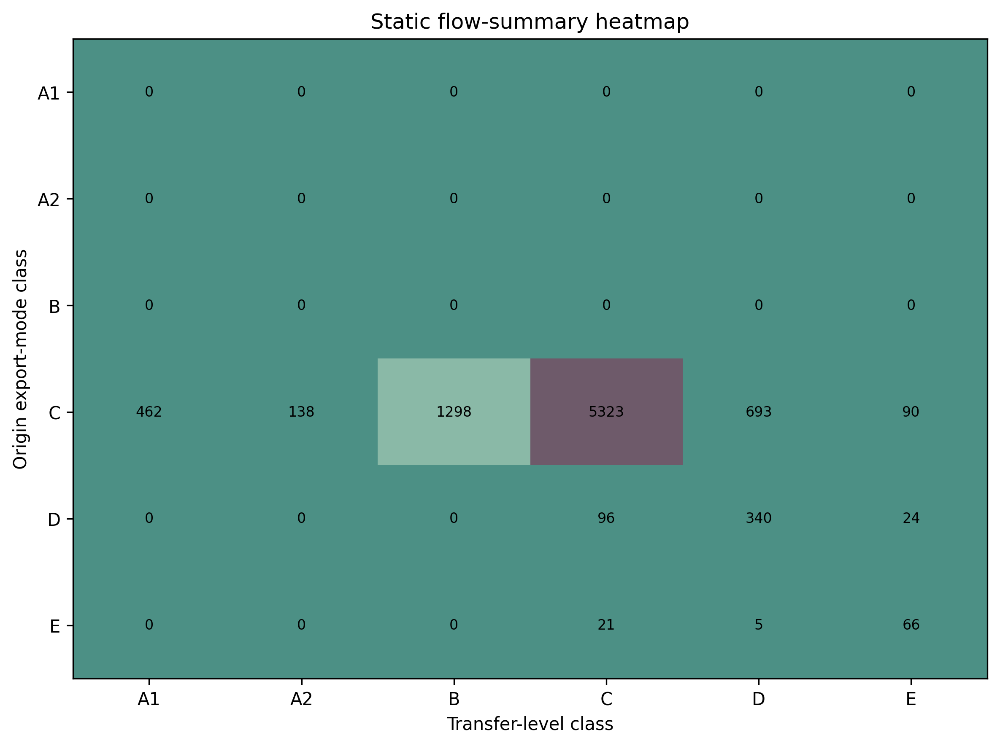

In [19]:
try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print("plotly is not installed. Static heatmap fallback will be used.")

if HAS_PLOTLY:
    left_nodes = [f"Origin mode {c}" for c in CATEGORY_ORDER]
    right_nodes = [f"Transfer {c}" for c in CATEGORY_ORDER]
    labels = left_nodes + right_nodes

    sources, targets, values, colors = [], [], [], []
    for i, origin_class in enumerate(CATEGORY_ORDER):
        for j, transfer_class in enumerate(CATEGORY_ORDER):
            val = int(flow_counts.loc[origin_class, transfer_class])
            if val > 0:
                sources.append(i)
                targets.append(len(CATEGORY_ORDER) + j)
                values.append(val)
                colors.append(PALETTE[transfer_class])

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=16,
            thickness=18,
            line=dict(color="black", width=0.3),
            label=labels,
            color=[PALETTE[c] for c in CATEGORY_ORDER] + [PALETTE[c] for c in CATEGORY_ORDER],
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
        )
    )])

    fig.update_layout(title_text="Alluvial summary of origin export mode to transfer-level class", font_size=11)
    fig.write_html(OUTDIR / "08_sankey_origin_mode_to_transfer_class.html")
    fig.show()
else:
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    im = ax.imshow(flow_counts.values, cmap=CMAP, aspect="auto")
    ax.set_xticks(range(len(CATEGORY_ORDER)))
    ax.set_yticks(range(len(CATEGORY_ORDER)))
    ax.set_xticklabels(CATEGORY_ORDER)
    ax.set_yticklabels(CATEGORY_ORDER)
    ax.set_xlabel("Transfer-level class")
    ax.set_ylabel("Origin export-mode class")
    ax.set_title("Static flow-summary heatmap")

    for i in range(flow_counts.shape[0]):
        for j in range(flow_counts.shape[1]):
            ax.text(j, i, int(flow_counts.iloc[i, j]), ha="center", va="center", fontsize=8)

    fig.tight_layout()
    savefig(fig, "08_static_flow_summary_heatmap")
    plt.show()


### Interpretation of the Sankey / flow summary

Wide flows indicate common combinations of origin export-mode class and actual transfer class. If most flow remains on the diagonal, country-level modal profiles are good summaries of the underlying transfer relationships. If flows spread widely across classes, then the mode is a poor summary and country profiles are more heterogeneous.

This plot is especially useful for evaluating whether modal maps are adequate. Strong off-diagonal flows indicate that the maps may be visually appealing but analytically incomplete.

## 9. Region-aggregated block matrix

The preceding analyses operate at the country level. This section aggregates the directed matrix into broader regions. The purpose is to ask whether legal friction is organized at the macro-regional scale, for example within Europe/UK, within Africa, or between Africa and Europe/UK.

The default region mapping is intentionally editable. It should be aligned with the regions used in the manuscript and with the coding logic used to construct the original matrix. The block matrix reports the mean ordinal friction across all directed country pairs from each origin region to each destination region.

In [20]:
# Edit or extend this dictionary to match your preferred regional classification.
EUROPE_UK = {
    "Germany","France","Italy","Spain","Netherlands","Belgium","Sweden","Austria","Finland",
    "Ireland","Denmark","Luxembourg","Czechia","Portugal","Lithuania","Estonia","Poland",
    "Greece","Hungary","Slovakia","Slovenia","Romania","United Kingdom","Switzerland",
    "Norway","Iceland","Croatia","Bulgaria","Latvia","Malta","Cyprus"
}

NORTH_AMERICA = {"United States", "United States of America", "Canada", "Mexico"}
LATIN_AMERICA = {
    "Argentina","Brazil","Chile","Colombia","Costa Rica","Peru","Uruguay","Ecuador",
    "Bolivia","Paraguay","Venezuela","Panama","Guatemala","Honduras","Nicaragua",
    "El Salvador","Dominican Republic"
}

def infer_region(country):
    if country in EUROPE_UK:
        return "Europe/UK"
    if country in NORTH_AMERICA:
        return "North America"
    if country in LATIN_AMERICA:
        return "Latin America"
    return "Africa / other"

region_map = {country: infer_region(country) for country in df_no_self.index}
regions = sorted(set(region_map.values()))

region_numeric = numeric_no_self.copy()
region_records = []
for origin_region in regions:
    origin_countries = [c for c in region_numeric.index if region_map[c] == origin_region]
    for dest_region in regions:
        dest_countries = [c for c in region_numeric.columns if region_map[c] == dest_region]
        vals = region_numeric.loc[origin_countries, dest_countries].to_numpy(copy=True).flatten()
        vals = pd.Series(vals).dropna().astype(float).values
        mean_val = np.nan if len(vals) == 0 else float(np.mean(vals))
        mode_val = np.nan if len(vals) == 0 else int(pd.Series(vals).mode().iloc[0])
        region_records.append({
            "origin_region": origin_region,
            "destination_region": dest_region,
            "mean_friction": mean_val,
            "mode_value": mode_val,
            "mode_class": VALUE_TO_CATEGORY.get(mode_val, np.nan),
        })

region_df = pd.DataFrame(region_records)
display(region_df)


,origin_region,destination_region,mean_friction,mode_value,mode_class
0,Africa / other,Africa / other,3.130468,3.0,C
1,Africa / other,Europe/UK,2.634615,3.0,C
2,Africa / other,Latin America,3.264423,3.0,C
3,Africa / other,North America,3.019231,3.0,C
4,Europe/UK,Africa / other,2.788462,3.0,C
5,Europe/UK,Europe/UK,0.163043,0.0,A1
6,Europe/UK,Latin America,3.250000,3.0,C
7,Europe/UK,North America,3.000000,3.0,C
8,Latin America,Africa / other,3.264423,3.0,C
9,Latin America,Europe/UK,2.375000,2.0,B


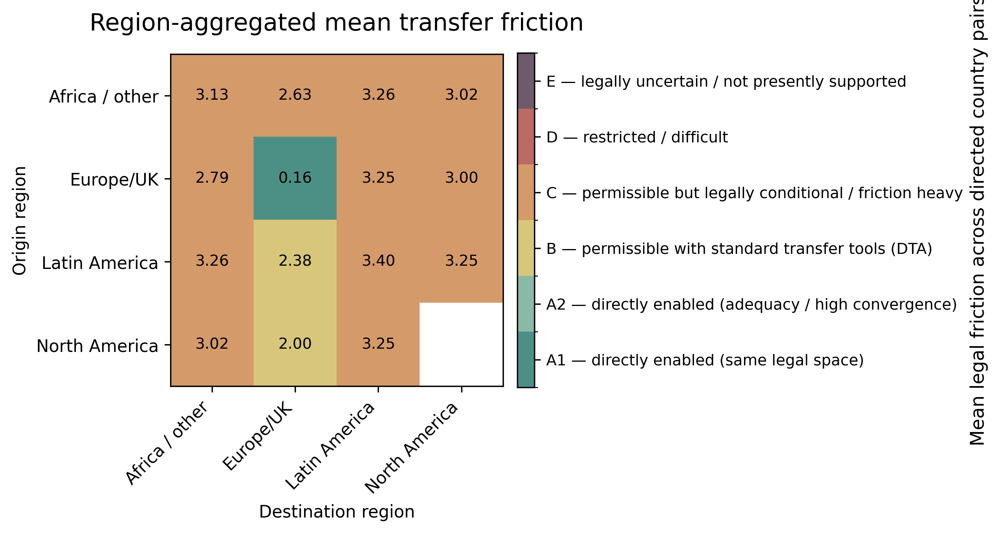

In [21]:
block = region_df.pivot(index="origin_region", columns="destination_region", values="mean_friction").loc[regions, regions]

fig, ax = plt.subplots(figsize=(8, 7), dpi=300)
im = ax.imshow(block.values.astype(float), cmap=CMAP, norm=NORM, interpolation="none", aspect="equal")

ax.set_xticks(range(len(regions)))
ax.set_yticks(range(len(regions)))
ax.set_xticklabels(regions, rotation=45, ha="right")
ax.set_yticklabels(regions)

for i in range(len(regions)):
    for j in range(len(regions)):
        val = block.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

add_category_colorbar(fig, ax, im, label="Mean legal friction across directed country pairs")
ax.set_title("Region-aggregated mean transfer friction", fontsize=14, pad=14)
ax.set_xlabel("Destination region")
ax.set_ylabel("Origin region")

fig.tight_layout()
savefig(fig, "09_region_aggregated_block_matrix")
plt.show()


### Interpretation of the region block matrix

Each cell summarizes the average legal friction for transfers from one region to another. Low values indicate broadly enabled or feasible data sharing. High values indicate greater conditionality, restriction, or uncertainty. Asymmetry between two off-diagonal cells, such as Region A → Region B versus Region B → Region A, suggests direction-specific regional imbalance.

Because this plot averages across many country pairs, it can hide within-region heterogeneity. It should be interpreted as a macro-level summary and checked against the country-level matrix and stacked profiles.

## 10. Parallel-coordinate country profiles

The stacked bar plot showed each country’s outgoing profile as a horizontal composition. This section uses a parallel-coordinate representation of the same information. Each line corresponds to one country, and the six axes correspond to the proportions of A1, A2, B, C, D, and E outgoing transfers.

This plot emphasizes the shape of profiles rather than country labels. It is useful for identifying whether countries follow a common pattern, whether there are multiple profile types, and whether some legal classes dominate the distribution.

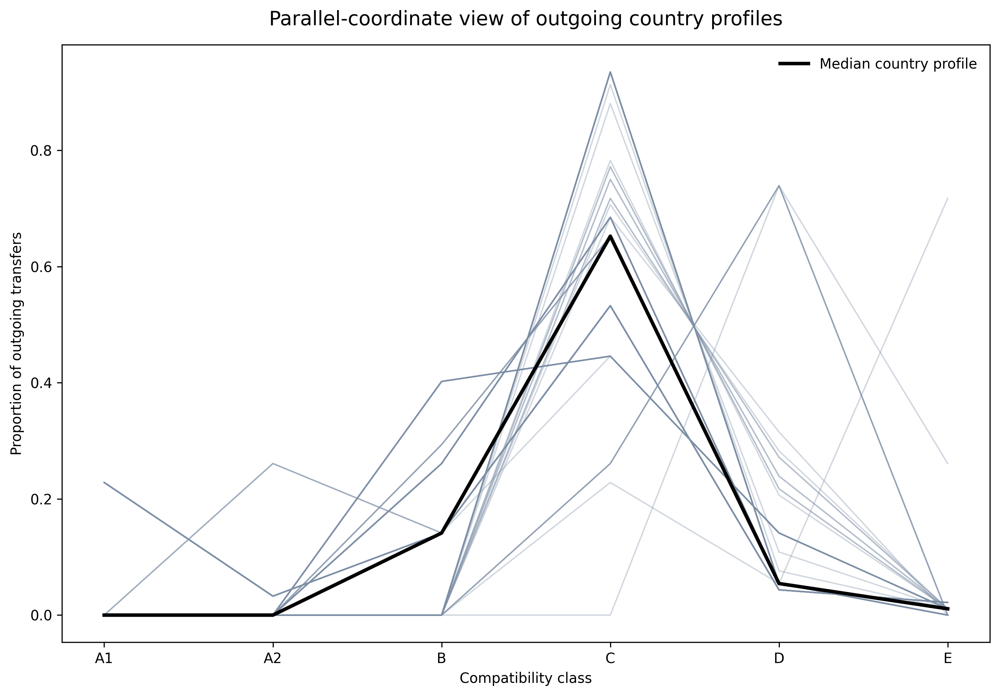

In [22]:
parallel_df = outgoing_dist.copy()
parallel_df["country"] = parallel_df.index

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

x = np.arange(len(CATEGORY_ORDER))
for _, row in parallel_df.iterrows():
    y = [row[c] for c in CATEGORY_ORDER]
    ax.plot(x, y, color="#7D8FA6", alpha=0.35, linewidth=1)

# Overlay median profile.
median_profile = parallel_df[CATEGORY_ORDER].median()
ax.plot(x, median_profile.values, color="black", linewidth=2.5, label="Median country profile")

ax.set_xticks(x)
ax.set_xticklabels(CATEGORY_ORDER)
ax.set_ylabel("Proportion of outgoing transfers")
ax.set_xlabel("Compatibility class")
ax.set_title("Parallel-coordinate view of outgoing country profiles", fontsize=14, pad=14)
ax.legend(frameon=False)

fig.tight_layout()
savefig(fig, "10_parallel_coordinate_country_profiles")
plt.show()


### Interpretation of the parallel-coordinate plot

The black line shows the median country profile. Individual gray lines show how each country deviates from that median. If most lines follow a similar shape, the countries share a common legal-profile structure. If lines cross heavily or spread widely, country profiles are heterogeneous.

This plot is less useful for identifying specific countries, but it is valuable for seeing whether the dataset contains common profile archetypes.

## 11. Row-normalized country-by-class heatmap

This section presents a compact alternative to the stacked bar plot. Each row is a country, each column is a legal class, and each cell is the proportion of that country’s outgoing transfers falling into that class.

The row-normalized heatmap preserves the same information as the stacked bar chart but emphasizes comparative intensity across classes. It is often easier to scan when the number of countries is large.

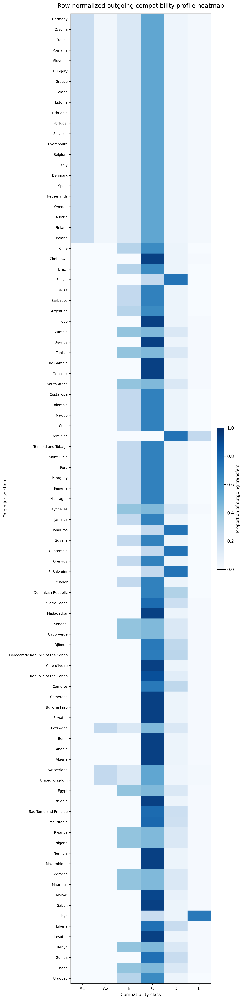

In [23]:
heat = outgoing_dist[CATEGORY_ORDER].copy()

fig, ax = plt.subplots(figsize=(8, max(10, len(heat) * 0.35)), dpi=300)
im = ax.imshow(heat.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(CATEGORY_ORDER)))
ax.set_xticklabels(CATEGORY_ORDER)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Proportion of outgoing transfers", fontsize=10)

ax.set_xlabel("Compatibility class")
ax.set_ylabel("Origin jurisdiction")
ax.set_title("Row-normalized outgoing compatibility profile heatmap", fontsize=14, pad=14)

fig.tight_layout()
savefig(fig, "11_row_normalized_country_class_heatmap")
plt.show()


### Interpretation of the row-normalized heatmap

Dark cells indicate that a large proportion of a country’s outgoing transfers fall into that class. A country with one dark cell and several light cells has a concentrated profile. A country with multiple medium-intensity cells has a more heterogeneous profile.

This plot provides a useful bridge between stacked profiles and entropy: visually concentrated rows should correspond to lower entropy, while visually diffuse rows should correspond to higher entropy.

## 12. Inequality / Lorenz-style analysis of average legal friction

The preceding sections describe structure, clustering, and heterogeneity. This final quantitative section asks whether legal friction is evenly distributed across countries or concentrated among a subset of jurisdictions.

For each origin country, the notebook computes the average outgoing legal-friction score using A1 = 0 through E = 5. The ranked bar plot shows which countries have higher or lower average friction. The Lorenz-style curve and Gini coefficient summarize whether friction is concentrated unevenly across countries.

,country,average_export_friction
0,Germany,2.195652
1,Romania,2.195652
2,Slovenia,2.195652
3,Hungary,2.195652
4,Greece,2.195652
...,...,...
88,Guatemala,3.739130
89,Honduras,3.739130
90,Bolivia,3.739130
91,Dominica,4.260870


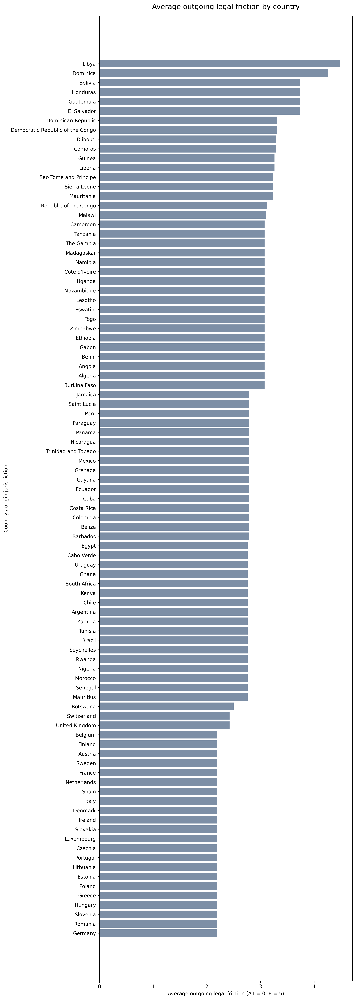

In [24]:
avg_export_friction = numeric_no_self.mean(axis=1, skipna=True).sort_values()
friction_df = pd.DataFrame({
    "country": avg_export_friction.index,
    "average_export_friction": avg_export_friction.values,
})

display(friction_df)

fig, ax = plt.subplots(figsize=(10, max(8, len(friction_df) * 0.3)), dpi=300)
ax.barh(friction_df["country"], friction_df["average_export_friction"], color="#7D8FA6")
ax.set_xlabel("Average outgoing legal friction (A1 = 0, E = 5)")
ax.set_ylabel("Country / origin jurisdiction")
ax.set_title("Average outgoing legal friction by country", fontsize=14, pad=14)

fig.tight_layout()
savefig(fig, "12a_average_export_friction_by_country")
plt.show()


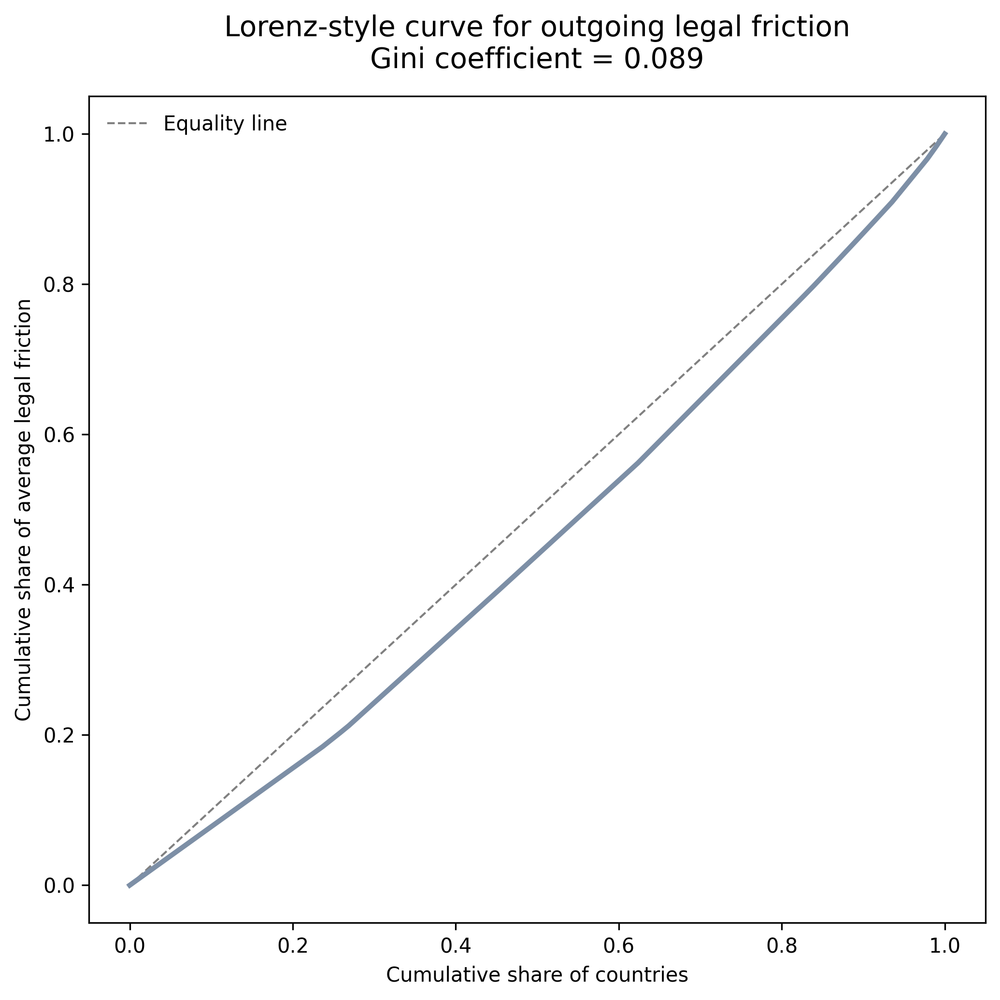

In [25]:
def gini_coefficient(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0 or np.all(x == 0):
        return np.nan
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

x = avg_export_friction.dropna().values
x_sorted = np.sort(x)
cum_friction = np.cumsum(x_sorted)
cum_friction_share = cum_friction / cum_friction[-1]
cum_country_share = np.arange(1, len(x_sorted) + 1) / len(x_sorted)

gini = gini_coefficient(x_sorted)

fig, ax = plt.subplots(figsize=(7, 7), dpi=300)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Equality line")
ax.plot(np.r_[0, cum_country_share], np.r_[0, cum_friction_share], color="#7D8FA6", linewidth=2.5)

ax.set_xlabel("Cumulative share of countries")
ax.set_ylabel("Cumulative share of average legal friction")
ax.set_title(f"Lorenz-style curve for outgoing legal friction\nGini coefficient = {gini:.3f}", fontsize=14, pad=14)
ax.legend(frameon=False)

fig.tight_layout()
savefig(fig, "12b_lorenz_curve_average_export_friction")
plt.show()


### Interpretation of the inequality analysis

The average-friction bar plot ranks countries by their typical outgoing legal difficulty. Higher values indicate more restrictive, conditional, or uncertain export environments. The Lorenz-style curve summarizes concentration: a curve close to the equality line indicates that friction is relatively evenly distributed across countries. A curve far below the equality line indicates that a smaller subset of countries accounts for a disproportionate share of legal friction.

The Gini coefficient is a compact scalar summary of this inequality. It should not replace the country-level plot, but it provides a useful way to compare versions of the matrix, regions, or future recoding iterations.

## Integrated interpretation guide

The notebook is designed as a sequence of increasingly abstract views of the same directed legal-interoperability matrix. The directional matrix is the primary evidence because it preserves all bilateral relationships. The stacked profiles, modal maps, entropy analyses, and average-friction measures summarize country-level behavior. The asymmetry matrix isolates reciprocity and nonreciprocity. The network analysis identifies hubs and bridges among feasible transfer pathways. The embedding and clustering analyses search for latent governance structure. The region block matrix provides a macro-level summary, and the inequality analysis quantifies whether friction is concentrated or broadly distributed.

A defensible manuscript interpretation should not rely on a single plot. Strong conclusions are those that appear consistently across multiple representations. For example, a country that appears restrictive in the matrix, has a high C/D/E stacked profile, high average friction, and low network out-strength is robustly characterized as a difficult exporter. A cluster that appears in the clustered heatmap, MDS, and UMAP is more persuasive than a cluster that appears only in t-SNE.

The recommended figure hierarchy is:

1. Use the directional matrix as the primary descriptive figure.
2. Use the asymmetry matrix to quantify reciprocity and directionality.
3. Use stacked profiles or row-normalized heatmaps to summarize country-level distributions.
4. Use clustering or MDS to identify governance families.
5. Use maps and networks as communicative secondary or supplementary figures.

## Technical note: read-only array fix

Some pandas and NumPy configurations expose `DataFrame.values` as a read-only view. Directly applying `np.fill_diagonal()` to such an array can produce the error:

```python
ValueError: underlying array is read-only
```

This notebook avoids that issue by using `remove_self_transfers()`, which first creates a writable NumPy copy and then replaces the diagonal with `NaN`. This approach is safer and should be used whenever self-transfers need to be removed from the matrix.